In [2]:
!pip install adjustText
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
!pip install --upgrade adjustText


[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: C:\Users\sainz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: C:\Users\sainz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
#caso esteja usando a tabela limpa V5, NÃO RODAR, as stopwords foram retiradas dela e a celula 3 faz o processo de manter apenas as palavras relevantes para a analise
#transformando a tabela de stopwords
import csv

# Configurações do arquivo
arquivo_csv = "StopWords_att_15_04.csv"
encoding = 'utf-8'  # Altere se necessário (latin-1, cp1252, etc)

# Processamento do arquivo
stopwords = set()

with open(arquivo_csv, 'r', encoding=encoding, errors='replace') as arquivo:
    leitor = csv.reader(arquivo)
    for linha in leitor:
        if linha:  # Verifica linhas não vazias
            termo = linha[0].strip()
            if termo:
                stopwords.add(termo)

# Função de formatação específica
def formatar_set(conjunto):
    if not conjunto:
        return 'set()'
    return 'set(["' + '", "'.join(sorted(conjunto)) + '"])'

# Saída formatada corretamente
print("Set no formato Python correto:")
print(formatar_set(stopwords))
print(f"\nTotal de termos: {len(stopwords)}")
print("\nExemplo inicial:")
print(formatar_set(set(list(stopwords)[:5])))  # Mostra 5 primeiros

Set no formato Python correto:
set(["VERDADEIRO", "a", "aa", "abafar", "abaixo", "abandonada", "abandonadas", "abbas", "abencoado", "abencoando", "abencoar", "abencoe", "abertamente", "abertas", "aberto", "abertos", "abiamb", "abilio", "abin", "abjeto", "abordagens", "abordara", "abordarmos", "abordei", "abraco", "abrangendo", "abrangente", "abras", "abrauto", "abre", "abrem", "abreu", "abriga", "abrigo", "abril", "abrilindigena", "abrimos", "abrindo", "abrir", "abro", "absoluta", "absolutamente", "absoluto", "absorventes", "absurdas", "absurdo", "absurdos", "abusiva", "abusivas", "acaba", "acabado", "acabam", "acabando", "acabar", "acabou", "academica", "acampamento", "acaso", "aceitam", "aceitar", "aceitaremos", "aceitava", "aceitavel", "aceite", "aceitou", "aceleradores", "acelerando", "acelerar", "acendesse", "acerca", "acertada", "acertado", "acessado", "acessando", "acessar", "acesse", "acessem", "acessivel", "acha", "acham", "achamos", "achismos", "acho", "acia", "acidente", "ac

In [7]:
import pandas as pd
import re

# Caminho do arquivo original
arquivo_entrada = "2023_Completo_posts_limpos_v6.xlsx"
arquivo_saida = "posts_filtrados_e_limpos.xlsx" # Nome do arquivo de saída alterado
COLUNAS_RELEVANTES = ['bloco', 'ideolodia', 'partido', 'Profile', 'texto_limpo']

# Carrega os dados
df = pd.read_excel(arquivo_entrada)

# --- Contagem de posts por Profile ANTES da filtragem ---
# Cria um mapeamento de Profile para a contagem total de seus posts no DataFrame original
contagem_posts_antes_filtro_por_profile = df.groupby('Profile').size()

# --- Definição dos Termos ---

# Moduladores de representação
termos_representacao = [
    "Representar", "represento", "representa", "representamos", "representam", "advogar", "advogo", "advoga",
    "advogamos", "advogam", "resguardar", "resguardo", "resguarda", "resguardamos", "resguardam", "salvaguardar",
    "salvaguardo", "salvaguarda", "salvaguardamos", "salvaguardam", "favorecer", "favoreço", "favorece",
    "favorecemos", "favorecem", "adotar", "adoto", "adota", "adotamos", "adotam", "posicionar", "posiciono",
    "posiciona", "posicionamos", "posicionam", "abraçar", "abraço", "abraça", "abraçamos", "abraçam", "patrocinar",
    "patrocino", "patrocina", "patrocinamos", "patrocinam", "ajudar", "ajudo", "ajuda", "ajudamos", "ajudam",
    "apoiar", "apoio", "apoia", "apoiamos", "apoiam", "amparar", "amparo", "ampara", "amparamos", "amparam",
    "personificar", "personifico", "personifica", "personificamos", "personificam", "defender", "defendo",
    "defende", "defendemos", "defendem", "saber", "sei", "sabe", "sabemos", "sabem", "simbolizar", "simbolizo",
    "simboliza", "simbolizamos", "lutar", "luto", "luta", "lutamos", "lutam", "resistir", "resisto", "resiste",
    "resistimos", "resistem", "opor", "oponho", "opõe", "opusemos", "opomos", "opuseram", "intervir", "intervenho",
    "intervem", "intervimos", "intervém", "proibir", "proibo", "proibe", "proibimos", "proibem"
]

# Todos os outros termos (objetos da representação)
termos_objeto = [
    # Geral (criminosos)
    "criminoso", "criminosa", "criminosos", "criminosas", "réu", "réus", "culpado", "culpada", "culpados", "culpadas",
    "delinquente", "delinquentes", "infrator", "infratora", "infratores", "infratoras", "transgressor", "transgressora",
    "transgressores", "transgressoras", "bandido", "bandida", "bandidos", "bandidas", "malfeitor", "malfeitora",
    "malfeitores", "malfeitoras", "marginal", "marginais", "milícia", "terrorista", "terroristas",
    # Geral (pessoas em geral)
    "cidadão", "cidadã", "cidadãos", "cidadãs", "habitante", "habitantes", "residente", "residentes", "morador",
    "moradora", "moradores", "moradoras", "pessoas", "sujeitos", "humanos", "população", "populações", "povo",
    "povos", "comunidade", "comunidades",
    # Geral (imigrantes)
    "imigrante", "imigrantes", "minoria", "minorias", "refugiado", "refugiada", "refugiados", "refugiadas",
    "asilado", "asilada", "asilados", "asiladas", "exilado", "exilada", "exilados", "exiladas",
    # Geográfico (nacional e regional)
    "latino", "latina", "latinos", "latinas", "latinoamericano", "latinoamericana", "latinoamericanos",
    "latinoamericanas", "brasileiro", "brasileira", "brasileiros", "brasileiras", "nortista", "nortistas",
    "nordestino", "nordestina", "nordestinos", "nordestinas", "sulista", "sulistas",
    # Geográfico (estadual)
    "acriano", "acriana", "acrianos", "acrianas", "alagoano", "alagoana", "alagoanos", "alagoanas", "alagoense", "alagoenses",
    "amapaense", "amapaenses", "amazonense", "amazonenses", "baiano", "baiana", "baianos", "baianas", "cearense", "cearenses",
    "espírito-santense", "espírito-santenses", "capixaba", "capixabas", "goiano", "goiana", "goianos", "goianas",
    "maranhense", "maranhenses", "mato-grossense", "mato-grossenses", "mato-grossense-do-sul", "mato-grossenses-do-sul",
    "sul-mato-grossense", "sul-mato-grossenses", "mineiro", "mineira", "mineiros", "mineiras", "paraense", "paraenses",
    "paraibano", "paraibana", "paraibanos", "paraibanas", "paranaense", "paranaenses", "paranista", "paranistas",
    "pernambucano", "pernambucana", "pernambucanos", "pernambucanas", "piauiense", "piauienses", "fluminense", "fluminenses",
    "rio-grandense-do-norte", "rio-grandenses-do-norte", "norte-rio-grandense", "norte-rio-grandenses", "potiguar", "potiguares",
    "rio-grandense-do-sul", "rio-grandenses-do-sul", "sul-rio-grandense", "sul-rio-grandenses", "gaúcho", "gaúcha",
    "gaúchos", "gaúchas", "rondoniense", "rondonienses", "rondoniano", "rondoniana", "rondonianos", "rondonianas",
    "roraimense", "roraimenses", "catarinense", "catarinenses", "santa-catarinense", "santa-catarinenses", "paulista", "paulistas",
    "sergipano", "sergipana", "sergipanos", "sergipanas", "sergipense", "sergipenses", "tocantinense", "tocantinenses",
    # Geográfico (capitais)
    "aracajuano", "aracajuana", "aracajuanos", "aracajuanas", "aracajuense", "aracajuenses", "belenense", "belenenses",
    "belo-horizontino", "belo-horizontina", "belo-horizontinos", "belo-horizontinas", "boa-vistense", "boa-vistenses",
    "campo-grandense", "campo-grandenses", "cuiabano", "cuiabana", "cuiabanos", "cuiabanas", "curitibano", "curitibana",
    "curitibanos", "curitibanas", "florianopolitano", "florianopolitana", "florianopolitanos", "florianopolitanas",
    "fortalezense", "fortalezenses", "goianense", "goianenses", "pessoense", "pessoenses", "macapaense",
    "maceioense", "maceioenses", "manauense", "manauenses", "manauara", "manauaras", "natalense", "natalenses",
    "palmense", "palmenses", "porto-alegrense", "porto-alegrenses", "porto-velhense", "porto-velhenses", "recifense", "recifenses",
    "rio-branquense", "rio-branquenses", "carioca", "cariocas", "soteropolitano", "soteropolitana", "soteropolitanos", "soteropolitanas",
    "salvadorense", "salvadorenses", "são-luisense", "são-luisenses", "ludovicense", "ludovicenses", "paulistano", "paulistana",
    "paulistanos", "paulistanas", "teresinense", "teresinenses", "vitoriense", "vitorienses",
    # Grupos médicos (condições)
    "PCD", "PCDs", "deficiência", "TEA", "TEAs", "TDAH",
    # Grupos médicos (vítimas de desastres, criminalidade, acidentes)
    "vítima", "vítimas", "desalojado", "desalojada", "desalojados", "desalojadas",
    # Mobilidade
    "motorista", "motoristas", "pedestre", "pedestres", "transeunte", "transeuntes", "ciclista", "ciclistas",
    "turista", "turistas", "piloto", "pilota", "pilotos", "pilotas",
    # Grupos Políticos (geral)
    "Eleitor", "Eleitora", "eleitores", "eleitoras", "simpatizante", "simpatizantes", "ativista", "ativistas",
    "militante", "militantes", "ONG", "ONGs", "sindicalista", "sindicalistas",
    # Grupos Políticos
    "Capitalismo", "Capitalista", "Capitalistas", "Centrista", "Centristas", "Comunismo", "Comunista", "Comunistas",
    "Conservador", "Conservadora", "Conservadores", "Conservadorismo", "Direita", "Direitista", "Direitistas",
    "Esquerda", "Esquerdista", "Esquerdistas", "Liberalismo", "Liberal", "Liberais",
    # Sociodemográficos (pessoas)
    "solteiro", "solteira", "solteiros", "solteiras", "família", "famílias", "vulneráveis", "crianças", "jovens", "bebês",
    "estudante", "estudantes", "gerações", "adolescentes", "idosos", "avô", "avó", "avôs", "avós",
    "avo", "avos", "pai", "pais", "mãe", "mães", "homens", "mulheres",
    # Sociodemográficos (grupos)
    "heterosexuais", "LGBT", "LGBTQIA+", "gays", "lesbicas", "trans", "travestis", "transsexuais", "bissexuais",
    "homosexuais", "queer", "cristãos", "católicos", "evangélicos", "muçulmanos", "judeus",
    "fundamentalistas", "brancos", "brancas", "negros", "negras", "pretas", "pretos", "indígenas",
    "originários", "índios", "pardos", "mulatos", "quilombolas", "marginalizado", "marginalizada",
    "marginalizados", "marginalizadas", "favelizado", "fevelizada", "favelizados", "favelizadas",
    # Socioeconômico (Situação e categorias abertas)
    "Ricos", "Bilionários", "Milionários", "desempregados", "Pobres", "beneficiários", "encarcerados",
    "encarceradas", "presos", "presas", "detidos", "detidas", "elites", "consumidores",
    # Socioeconômico (categorias profissionais)
    "Chefes", "Patrões", "Empregadores", "Trabalhadores", "Empregados", "Advogadas", "Advogados",
    "Agricultoras", "Agricultores", "Arquitetas", "Arquitetos", "Artistas", "Atendentes",
    "Atletas", "Bombeiras", "Bombeiros", "Cientistas", "Comerciantes", "Desembargadores",
    "Diplomatas", "Domésticas", "Empresárias", "Empresários", "Enfermeiras", "Enfermeiros", "Engenheiras", "Engenheiros",
    "Entregadores", "Faxineiras", "Faxineiros", "Funcionárias", "Funcionários", "Influencers",
    "Influenciadores", "Investidores", "Rentistas", "Jornalistas", "Juízas", "Juízes", "Médicas",
    "Médicos", "Militares", "Motoboys", "Mototaxistas", "Paramédicas", "Paramédicos", "Policiais",
    "Políticos", "Porteiros", "Professoras", "Professores", "Radialistas", "Secretárias",
    "Taxistas", "autônomos", "Vendedoras", "Vendedores", "carcerários", "bancários", "soldados",
    "garçons", "recepcionistas", "acadêmicos", "experts", "pedagogos", "pedagogas", "músicos",
    "musicistas", "pintores", "escultores", "fazendeiros", "multinacionais", "empresas",
    "companhias", "servidores",
]

# Lista completa de termos para a função de limpeza (texto_filtrado)
termos_validos_completos = termos_objeto + termos_representacao

# --- Criação dos Regex ---
regex_representacao_filtro = r'\b(?:' + '|'.join(map(re.escape, termos_representacao)) + r')\b'
regex_objeto_filtro = r'\b(?:' + '|'.join(map(re.escape, termos_objeto)) + r')\b'
regex_limpeza_total = r'\b(?:' + '|'.join(map(re.escape, termos_validos_completos)) + r')\b'

def limpar_texto(texto):
    palavras_filtradas = re.findall(regex_limpeza_total, str(texto).lower())
    return ' '.join(palavras_filtradas)

num_total_posts_dataset_original = len(df) # Renomeado para clareza

df['texto_limpo_str'] = df['texto_limpo'].astype(str)

condicao_tem_representacao = df['texto_limpo_str'].str.contains(regex_representacao_filtro, flags=re.IGNORECASE, na=False)
condicao_tem_objeto = df['texto_limpo_str'].str.contains(regex_objeto_filtro, flags=re.IGNORECASE, na=False)

posts_com_termos = df[condicao_tem_representacao & condicao_tem_objeto].copy()

# --- Adicionar colunas de contagem ---
# 1. Mapear a contagem de posts ANTES do filtro para cada Profile no DataFrame filtrado
posts_com_termos['total_posts_profile_antes_filtro'] = posts_com_termos['Profile'].map(contagem_posts_antes_filtro_por_profile)

# 2. Calcular e adicionar a contagem de posts DEPOIS do filtro para cada Profile
#    .transform('size') calcula o tamanho de cada grupo (Profile) e o atribui de volta a cada linha do grupo.
posts_com_termos['total_posts_profile_depois_filtro'] = posts_com_termos.groupby('Profile')['Profile'].transform('size')


posts_com_termos['texto_filtrado'] = posts_com_termos['texto_limpo_str'].apply(limpar_texto)

num_filtrados = len(posts_com_termos)
retencao = (num_filtrados / num_total_posts_dataset_original) * 100 if num_total_posts_dataset_original > 0 else 0

print(f"Total de posts originais no dataset: {num_total_posts_dataset_original}")
print(f"Total de posts após filtragem combinada: {num_filtrados}")
print(f"Taxa de retenção: {retencao:.2f}%")

# --- Preparar colunas para saída ---
novas_colunas_contagem = ['total_posts_profile_antes_filtro', 'total_posts_profile_depois_filtro']
colunas_saida = COLUNAS_RELEVANTES + ['texto_filtrado'] + novas_colunas_contagem
colunas_saida_existentes = [col for col in colunas_saida if col in posts_com_termos.columns]

# Adiciona as novas colunas de contagem à lista de colunas de saída, se ainda não estiverem (garantia)
for nova_col in novas_colunas_contagem:
    if nova_col not in colunas_saida_existentes and nova_col in posts_com_termos.columns:
        colunas_saida_existentes.append(nova_col)


posts_com_termos[colunas_saida_existentes].to_excel(arquivo_saida, index=False)

print("Arquivo salvo em:", arquivo_saida)

Total de posts originais no dataset: 311247
Total de posts após filtragem combinada: 44073
Taxa de retenção: 14.16%
Arquivo salvo em: posts_filtrados_e_limpos.xlsx


                  Profile    coesao  total_posts_profile_antes_filtro  \
136         Dimas Fabiano  0.489076                               384   
99         Célia Xakriabá  0.333808                              1197   
369         Pastor Eurico  0.286823                               383   
102            Da Vitoria  0.263055                               611   
80       Celso Russomanno  0.261754                               186   
355  Mário Negromonte Jr.  0.244069                               400   
53           Baleia Rossi  0.229386                               283   
288       Luciano Azevedo  0.222802                               156   
21             Alfredinho  0.208119                               884   
159      Elmar Nascimento  0.205709                               148   

     total_posts_profile_depois_filtro  num_publicacoes  
136                                135              135  
99                                 531              531  
369                   

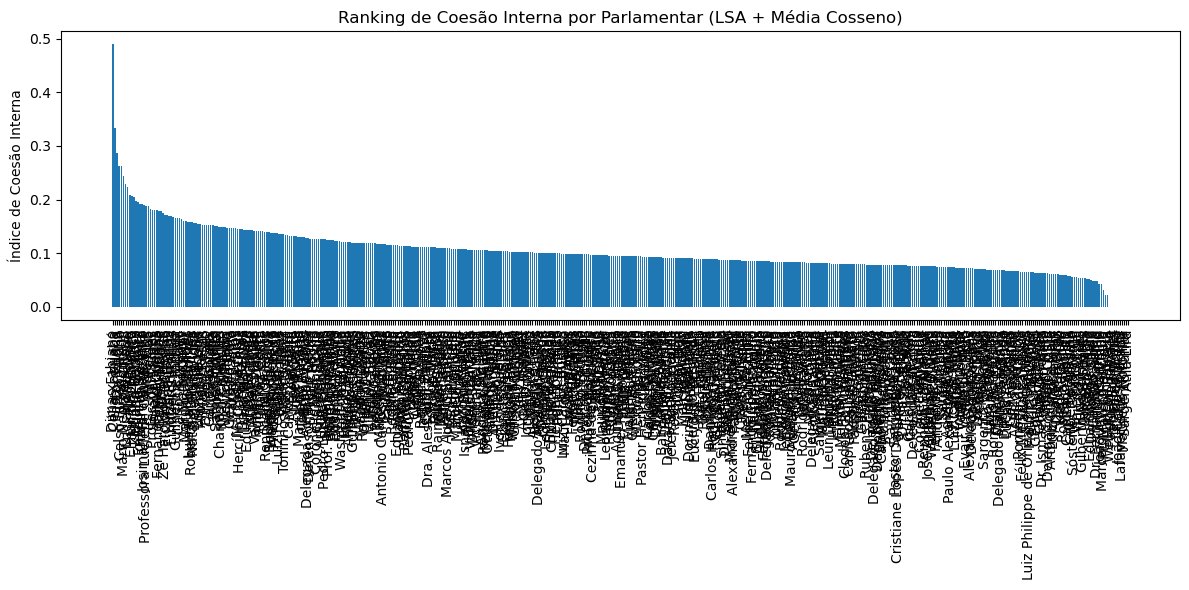

In [8]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# 1. Carregar a base de dados de postagens já limpa
# !!! ATENÇÃO: Certifique-se de que este é o nome do arquivo gerado pelo script anterior
# que CONTÉM as colunas 'total_posts_profile_antes_filtro' e 'total_posts_profile_depois_filtro'.
# Exemplo: "posts_filtrados_e_limpos_combinacao_contagens.xlsx"
arquivo_entrada_filtrado = "posts_filtrados_e_limpos_combinacao_contagens.xlsx" # AJUSTE ESTE NOME DE ARQUIVO SE NECESSÁRIO
df = pd.read_excel(arquivo_entrada_filtrado)

# Pré-processamento crítico
df['texto_filtrado'] = df['texto_filtrado'].fillna('').astype(str)

# Verificar se as colunas esperadas existem, caso contrário, preencher com NaN para evitar erros posteriores
# Isso é uma salvaguarda caso o arquivo de entrada não tenha as colunas.
colunas_contagem_esperadas = ['total_posts_profile_antes_filtro', 'total_posts_profile_depois_filtro']
for col in colunas_contagem_esperadas:
    if col not in df.columns:
        print(f"AVISO: Coluna '{col}' não encontrada no arquivo de entrada. Será preenchida com NaN.")
        df[col] = np.nan


# 2. Vetorização TF-IDF de cada postagem individualmente
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df['texto_filtrado'])

# 3. Aplicar LSA global (sobre todas as postagens)
n_topics = 100  # você pode ajustar este valor
tsvd = TruncatedSVD(n_components=n_topics, random_state=42)
X_lsa = tsvd.fit_transform(X_tfidf)

# 4. Anexar o vetor LSA ao DataFrame
df['vec_lsa'] = list(X_lsa)

# 5. Função para calcular índice de coesão (mean pairwise cosine similarity)
def cohesion_index(vectors: np.ndarray) -> float:
    """
    Recebe um array de vetores (shape: n_posts × n_topics) e retorna a média das
    similaridades cosseno sobre todos os pares i<j.
    """
    n = vectors.shape[0]
    if n < 2:
        return np.nan  # não há pares para calcular
    S = cosine_similarity(vectors)
    # extrair elementos acima da diagonal
    triu = S[np.triu_indices(n, k=1)]
    return triu.mean()

# 6. Calcular o índice de coesão para cada parlamentar e incluir contagens anteriores
cohesion_data_list = []
for profile, grp in df.groupby('Profile'):
    vecs = np.vstack(grp['vec_lsa'].values)
    score = cohesion_index(vecs)
    
    # Extrai os valores das colunas de contagem (são constantes dentro do grupo)
    # .iloc[0] pega o valor da primeira linha do grupo
    posts_antes = grp['total_posts_profile_antes_filtro'].iloc[0]
    posts_depois = grp['total_posts_profile_depois_filtro'].iloc[0]
    
    cohesion_data_list.append({
        'Profile': profile,
        'coesao': score,
        'total_posts_profile_antes_filtro': posts_antes,
        'total_posts_profile_depois_filtro': posts_depois
    })

df_cohesao = pd.DataFrame(cohesion_data_list)

# 7. Contagem de publicações por deputado (Profile) no arquivo atual (df)
# Esta contagem deve ser igual a 'total_posts_profile_depois_filtro' se tudo estiver correto.
counts = df['Profile'].value_counts().reset_index()
counts.columns = ['Profile', 'num_publicacoes']

# Merge da contagem com o dataframe de coesão
df_cohesao = df_cohesao.merge(counts, on='Profile', how='left') # Usado how='left' para manter todos os perfis de df_cohesao

# 8. Ordenar e salvar resultados
df_cohesao = df_cohesao.sort_values('coesao', ascending=False)
print(df_cohesao.head(10))  # top 10 parlamentares mais coesos

df_cohesao.to_csv('cohesion_scores_perfil.csv', index=False)
print("\nArquivo 'cohesion_scores_perfil.csv' salvo com sucesso.")
print("Colunas no arquivo final:", df_cohesao.columns.tolist())


# 9. (Opcional) Plotar ranking de coesão
# Verifica se há dados para plotar
if not df_cohesao.empty and 'coesao' in df_cohesao.columns and not df_cohesao['coesao'].isnull().all():
    plt.figure(figsize=(12, 6)) # << MODIFICAÇÃO: Tamanho da figura revertido para o padrão original
    plt.bar(df_cohesao['Profile'], df_cohesao['coesao'].fillna(0)) # Preenche NaN com 0 para plotagem
    plt.xticks(rotation=90)
    plt.ylabel('Índice de Coesão Interna')
    plt.title('Ranking de Coesão Interna por Parlamentar (LSA + Média Cosseno)')
    plt.tight_layout()
    try:
        plt.show()
    except Exception as e:
        print(f"Não foi possível exibir o gráfico interativamente: {e}")
        plt.savefig('cohesion_ranking_plot.png')
        print("Gráfico salvo como 'cohesion_ranking_plot.png'")
else:
    print("\nNão há dados de coesão suficientes ou válidos para gerar o gráfico.")

Calculando coesão: 100%|████████████████████████████████████████████████████████████| 490/490 [00:00<00:00, 942.47it/s]



Arquivo 'indice_coesao_interna_perfil.csv' salvo com sucesso.
Colunas no arquivo final de coesão: ['Profile', 'Mean_Cosine', 'Median_Cosine', 'Partido', 'Estado', 'total_posts_profile_antes_filtro', 'total_posts_profile_depois_filtro', 'num_publicacoes_neste_df']


Exportando matrizes: 100%|███████████████████████████████████████████████████████████| 490/490 [00:20<00:00, 23.61it/s]


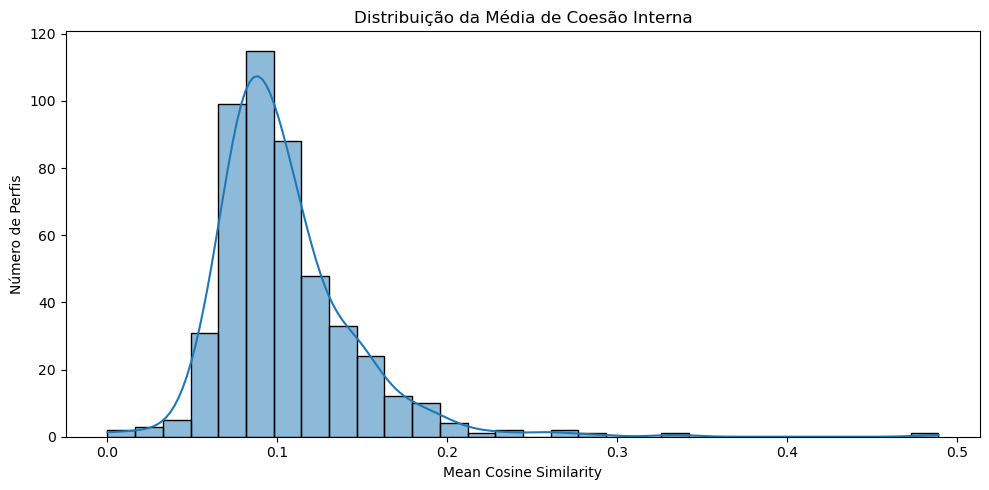

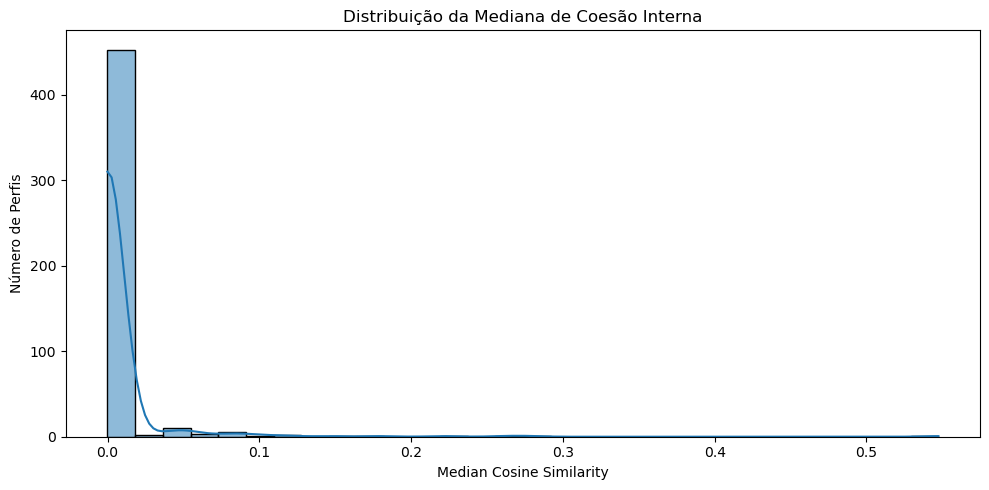

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


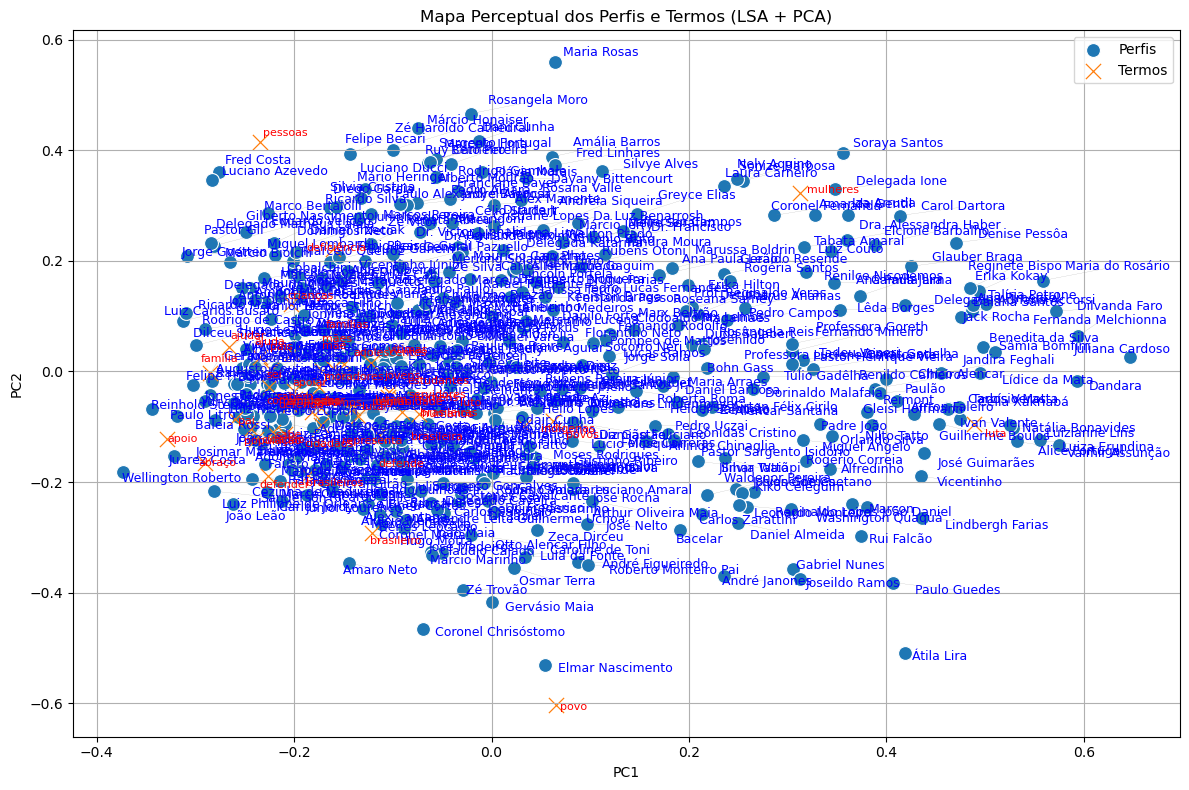

In [9]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import re

# -- 0. Carregar e pré-processar ------------------------------------------------
# !!! ATENÇÃO: Certifique-se de que este é o nome do arquivo gerado pelo script
# que CONTÉM as colunas 'total_posts_profile_antes_filtro' e 'total_posts_profile_depois_filtro'.
# Exemplo: "posts_filtrados_e_limpos_combinacao_contagens.xlsx"
arquivo_entrada_com_contagens = "posts_filtrados_e_limpos.xlsx" # AJUSTE ESTE NOME DE ARQUIVO SE NECESSÁRIO
df = pd.read_excel(arquivo_entrada_com_contagens)

df['texto_filtrado'] = df['texto_filtrado'].fillna('').astype(str)
df = df[df['texto_filtrado'].str.strip().str.len() > 0].copy() # Adicionado .copy() para evitar SettingWithCopyWarning

# Verificar se as colunas esperadas existem, caso contrário, preencher com NaN.
colunas_contagem_esperadas = ['total_posts_profile_antes_filtro', 'total_posts_profile_depois_filtro']
for col in colunas_contagem_esperadas:
    if col not in df.columns:
        print(f"AVISO: Coluna '{col}' não encontrada no arquivo de entrada '{arquivo_entrada_com_contagens}'. Será preenchida com NaN.")
        df[col] = np.nan

# -- 1. Vetorização TF-IDF e LSA global -----------------------------------------
vectorizer = TfidfVectorizer()
X_tfidf_all = vectorizer.fit_transform(df['texto_filtrado'])
dim = X_tfidf_all.shape[1] - 1
n_topics = min(100, dim) if dim > 1 else 1
lsa = TruncatedSVD(n_components=n_topics, random_state=42)
X_lsa_all = lsa.fit_transform(X_tfidf_all)
df['vec_lsa'] = list(X_lsa_all)

# -- 2. Funções de coesão ------------------------------------------------------
def cohesion_indices(vectors):
    n = vectors.shape[0]
    if n < 2:
        return np.nan, np.nan
    S = cosine_similarity(vectors)
    tri = S[np.triu_indices(n, k=1)]
    return float(tri.mean()), float(np.median(tri))

# -- 3. Índice de coesão por perfil --------------------------------------------
cohesion_scores = []
for profile, grp in tqdm(df.groupby('Profile'), desc='Calculando coesão'):
    vecs = np.vstack(grp['vec_lsa'].values)
    mean_cos, med_cos = cohesion_indices(vecs)
    extra = grp.iloc[0].to_dict() # Pega a primeira linha do grupo para 'partido' e 'estado'

    # Extrai os valores das colunas de contagem (são constantes dentro do grupo)
    posts_antes = grp['total_posts_profile_antes_filtro'].iloc[0]
    posts_depois = grp['total_posts_profile_depois_filtro'].iloc[0]
    
    cohesion_scores.append({
        'Profile': profile,
        'Mean_Cosine': mean_cos,
        'Median_Cosine': med_cos,
        'Partido': extra.get('partido', np.nan),
        'Estado': extra.get('estado', np.nan), # Supondo que 'estado' possa existir no seu df original
        'total_posts_profile_antes_filtro': posts_antes,
        'total_posts_profile_depois_filtro': posts_depois,
        'num_publicacoes_neste_df': len(grp) # Número de publicações usadas para calcular a coesão neste script
    })

df_cohesao = pd.DataFrame(cohesion_scores).sort_values('Mean_Cosine', ascending=False)
df_cohesao.to_csv('indice_coesao_interna_perfil.csv', index=False)
print("\nArquivo 'indice_coesao_interna_perfil.csv' salvo com sucesso.")
print("Colunas no arquivo final de coesão:", df_cohesao.columns.tolist())


# -- 4. Matriz de similaridade intra-perfil -----------------------------------
for profile, grp in tqdm(df.groupby('Profile'), desc='Exportando matrizes'):
    vecs = np.vstack(grp['vec_lsa'].values)
    if vecs.shape[0] < 2:
        continue
    sim_mat = cosine_similarity(vecs)
    idx = [f'post_{i}' for i in range(vecs.shape[0])]
    safe_name = re.sub(r'[^0-9a-zA-Z]+', '_', profile).strip('_')
    filename = f'sim_matrix_{safe_name}.csv'
    pd.DataFrame(sim_mat, index=idx, columns=idx).to_csv(filename)

# -- 5. Visualizações dos índices ---------------------------------------------
if not df_cohesao.empty:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_cohesao['Mean_Cosine'].dropna(), bins=30, kde=True)
    plt.title('Distribuição da Média de Coesão Interna')
    plt.xlabel('Mean Cosine Similarity')
    plt.ylabel('Número de Perfis')
    plt.tight_layout()
    try:
        plt.show()
    except Exception as e:
        print(f"Não foi possível exibir o gráfico de Média de Coesão: {e}. Tentando salvar...")
        plt.savefig('distribuicao_media_coesao.png')
        print("Gráfico salvo como 'distribuicao_media_coesao.png'")


    plt.figure(figsize=(10, 5))
    sns.histplot(df_cohesao['Median_Cosine'].dropna(), bins=30, kde=True)
    plt.title('Distribuição da Mediana de Coesão Interna')
    plt.xlabel('Median Cosine Similarity')
    plt.ylabel('Número de Perfis')
    plt.tight_layout()
    try:
        plt.show()
    except Exception as e:
        print(f"Não foi possível exibir o gráfico de Mediana de Coesão: {e}. Tentando salvar...")
        plt.savefig('distribuicao_mediana_coesao.png')
        print("Gráfico salvo como 'distribuicao_mediana_coesao.png'")

else:
    print("DataFrame de coesão está vazio. Gráficos de distribuição não gerados.")


# -- 6. Mapa perceptual com PCA e termos ---------------------------------------
# 6.1 Agrupar mensagens por Profile
df_grouped = df.groupby('Profile')['texto_filtrado'].apply(lambda x: ' '.join(x)).reset_index()

if not df_grouped.empty:
    # 6.2 Transformar agrupado pelo mesmo pipeline LSA
    X_tfidf_grp = vectorizer.transform(df_grouped['texto_filtrado']) # Usa o vectorizer já treinado
    X_lsa_grp = lsa.transform(X_tfidf_grp) # Usa o lsa já treinado
    
    # 6.3 Ajustar PCA em perfis
    # Garante que n_components do PCA não seja maior que o número de features ou samples
    n_components_pca = min(2, X_lsa_grp.shape[0], X_lsa_grp.shape[1])
    if n_components_pca < 2:
        print(f"Não é possível realizar PCA com {n_components_pca} componentes. Pulando mapa perceptual.")
    else:
        pca = PCA(n_components=n_components_pca, random_state=42)
        X_pca_profiles = pca.fit_transform(X_lsa_grp)
        df_pca = pd.DataFrame(X_pca_profiles, index=df_grouped['Profile'], columns=[f'PC{i+1}' for i in range(n_components_pca)])

        # 6.4 Selecionar termos mais frequentes
        all_words = ' '.join(df_grouped['texto_filtrado']).split()
        if all_words: # Procede apenas se houver palavras
            word_freq = Counter(all_words)
            top_words = [w for w,_ in word_freq.most_common(50)]

            # 6.5 Extrair vetores de termos do LSA (componentes)
            terms_in_vectorizer = vectorizer.get_feature_names_out()
            term_index = {term: idx for idx, term in enumerate(terms_in_vectorizer)}
            term_vecs_lsa = [] # Vetores dos termos no espaço LSA
            valid_terms_for_pca = []
            
            # lsa.components_ tem shape (n_topics, n_features_tfidf)
            # Precisamos transpor para (n_features_tfidf, n_topics) para projetar os termos
            # Ou, para cada termo, pegar sua representação no espaço LSA (que não é direto assim)
            # A forma correta de obter a representação LSA de um termo é mais complexa.
            # O que o script original parece querer é projetar os *vetores originais dos componentes LSA* para os termos
            # que estão nas colunas de lsa.components_.
            # Ou seja, cada 'componente LSA' (tópico) é um vetor sobre o vocabulário.
            # E cada termo tem um 'loading' em cada componente LSA.
            
            # Se a intenção é obter a representação dos termos no espaço LSA aprendido,
            # e depois projetar isso no PCA dos perfis, isso é um pouco conceitualmente diferente.
            # O que o código original faz com `lsa.components_[:, j]` é pegar o vetor de loadings do termo j
            # através dos tópicos. Isso é uma representação do termo no espaço dos tópicos.
            
            # Vetores dos termos no espaço LSA (cada termo é um vetor de dimensão n_topics)
            # (n_terms, n_topics)
            # Para isso, precisamos da matriz termo-tópico, que é X_lsa_all (posts x topicos)
            # ou lsa.components_ (topicos x termos)
            # Se lsa.components_ é (n_topics, n_vocab), então lsa.components_.T é (n_vocab, n_topics)
            # Esta é a representação de cada termo no espaço LSA.
            
            lsa_term_representation = lsa.components_.T # Shape: (n_vocab, n_topics)

            for w in top_words:
                j = term_index.get(w) # Índice do termo no vocabulário do TF-IDF
                if j is not None:
                    term_vec_lsa = lsa_term_representation[j, :] # Vetor do termo no espaço LSA
                    term_vecs_lsa.append(term_vec_lsa)
                    valid_terms_for_pca.append(w)
            
            if valid_terms_for_pca:
                term_vecs_lsa_stack = np.vstack(term_vecs_lsa) # shape: (n_valid_terms, n_topics)

                # 6.6 Projetar termos no PCA (que foi treinado nos perfis)
                X_pca_terms = pca.transform(term_vecs_lsa_stack) # Usa o pca treinado nos perfis
                df_pca_terms = pd.DataFrame(X_pca_terms, index=valid_terms_for_pca, columns=[f'PC{i+1}' for i in range(n_components_pca)])

                # 6.7 Plot geral
                plt.figure(figsize=(12,8))
                sns.scatterplot(x='PC1', y='PC2', data=df_pca, s=100, label='Perfis')
                sns.scatterplot(x='PC1', y='PC2', data=df_pca_terms, marker='x', s=120, label='Termos', legend=False) # Removido legend para evitar duplicata
                texts = []
                for idx in df_pca.index:
                    texts.append(plt.text(df_pca.loc[idx,'PC1'], df_pca.loc[idx,'PC2'], idx, fontsize=9, color='blue'))
                for term_idx in df_pca_terms.index: # Alterado para term_idx para evitar conflito com a variável 'terms' anterior
                    texts.append(plt.text(df_pca_terms.loc[term_idx,'PC1'], df_pca_terms.loc[term_idx,'PC2'], term_idx, fontsize=8, color='red'))
                
                if texts: # Só chama adjust_text se houver textos para ajustar
                    adjust_text(texts, only_move={'points':'xy','text':'xy'}, 
                                expand_points=(1.2,1.2), expand_text=(1.2,1.2), 
                                arrowprops=dict(arrowstyle='-', color='gray', lw=0.1))
                
                plt.title('Mapa Perceptual dos Perfis e Termos (LSA + PCA)')
                plt.xlabel('PC1')
                plt.ylabel('PC2')
                plt.legend(loc='upper right')
                plt.grid(True)
                plt.tight_layout()
                try:
                    plt.show()
                except Exception as e:
                    print(f"Não foi possível exibir o Mapa Perceptual: {e}. Tentando salvar...")
                    plt.savefig('mapa_perceptual_lsa_pca.png')
                    print("Gráfico salvo como 'mapa_perceptual_lsa_pca.png'")
            else:
                print("Nenhum termo válido encontrado para o mapa perceptual de termos.")
        else:
            print("Não há palavras para gerar o mapa perceptual.")
else:
    print("DataFrame agrupado está vazio. Mapa perceptual não gerado.")

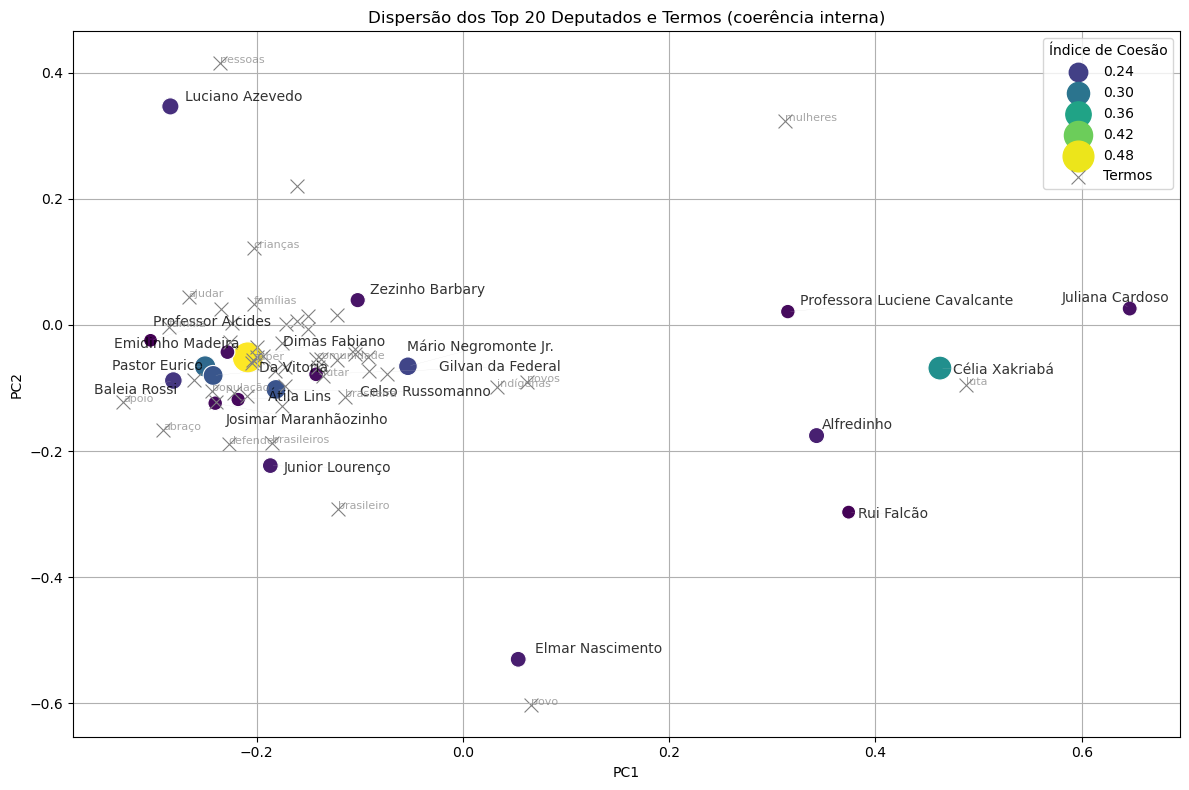

In [10]:
# -- 7. Dispersão de top 20 perfis vs termos com índice de coesão ----------------------
# Seleciona os 20 parlamentares com maior coesão média
top_n = 20
df_top = df_cohesao.nlargest(top_n, 'Mean_Cosine').set_index('Profile')
# Filtra coordenadas dos top perfis e seus índices
df_plot = df_pca.loc[df_top.index].join(df_top[['Mean_Cosine']])

plt.figure(figsize=(12,8))
# Plot perfis top 20 coloridos pelo índice de coesão
sns.scatterplot(
    x='PC1', y='PC2', data=df_plot, size='Mean_Cosine', hue='Mean_Cosine',
    palette='viridis', legend='brief', sizes=(100, 500)
)
# Plot termos em cinza
sns.scatterplot(
    x='PC1', y='PC2', data=df_pca_terms, marker='x', s=100, color='gray', label='Termos'
)

# Anotações só para os top 20 perfis
texts_profiles = []
for idx in df_plot.index:
    texts_profiles.append(plt.text(
        df_plot.loc[idx, 'PC1'], df_plot.loc[idx, 'PC2'], idx,
        fontsize=10, color='black', alpha=0.8
    ))
# Anotações apenas para os top 20 termos (sem ajuste)
top_terms_annot = df_pca_terms.head(20)
for term in top_terms_annot.index:
    plt.text(
        df_pca_terms.loc[term, 'PC1'], df_pca_terms.loc[term, 'PC2'], term,
        fontsize=8, color='gray', alpha=0.7
    )
# Ajusta apenas os perfis anotados para evitar grande custo de memória
adjust_text(
    texts_profiles,
    only_move={'points':'xy','text':'xy'},
    expand_points=(2,2), expand_text=(5,5),
    arrowprops=dict(arrowstyle='-', color='lightgray', lw=0.1, shrinkA=5)
)

plt.title(f'Dispersão dos Top {top_n} Deputados e Termos (coerência interna)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Índice de Coesão', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()



In [13]:
# -- 8. Tabela de top 15 palavras por parlamentar com coesão, partido, estado e nº de publicações --
rows = []
for profile, grp in df.groupby('Profile'):
    texts = grp['texto_filtrado'].tolist()
    freq = Counter(" ".join(texts).split())
    top15 = freq.most_common(15)
    meta = df_cohesao.set_index('Profile').loc[profile]
    num_posts = len(grp)  # número de publicações do parlamentar
    for word, count in top15:
        rows.append({
            'Profile': profile,
            'Partido': meta['Partido'],
            'Estado': meta['Estado'],
            'Mean_Cosine': meta['Mean_Cosine'],
            'N_Publicacoes': num_posts,  # nova coluna adicionada
            'Word': word,
            'Count': count
        })

df_word_table = pd.DataFrame(rows)

# Exporta o CSV
df_word_table.to_csv('top15_palavras_por_parlamentar.csv', index=False)

# Exibe as primeiras linhas
df_word_table.head(50)  # ajuste conforme desejar

,Profile,Partido,Estado,Mean_Cosine,N_Publicacoes,Word,Count
0,AJ Albuquerque,PP,NaN,0.103748,6,cearenses,2
1,AJ Albuquerque,PP,NaN,0.103748,6,cearense,2
2,AJ Albuquerque,PP,NaN,0.103748,6,sabe,2
3,AJ Albuquerque,PP,NaN,0.103748,6,moradores,1
4,AJ Albuquerque,PP,NaN,0.103748,6,apoio,1
5,AJ Albuquerque,PP,NaN,0.103748,6,sabemos,1
6,AJ Albuquerque,PP,NaN,0.103748,6,famílias,1
7,AJ Albuquerque,PP,NaN,0.103748,6,pessoas,1
8,AJ Albuquerque,PP,NaN,0.103748,6,família,1
9,AJ Albuquerque,PP,NaN,0.103748,6,comunidades,1
